# Zero-Shot Evaluation Results

## Load Results

Load the file paths to the specified model's zero-shot inference results on each dataset.

In [62]:
from pathlib import Path

model_name = "timesfm"
split_name = "pretrain"

csv_paths = list(Path("results/timesfm/pretrain").rglob("*.csv"))

print(f"Number of results files: {len(csv_paths)}")
print(f"Example CSV path: {csv_paths[0]}")

Number of results files: 55
Example CSV path: results\timesfm\pretrain\australian_electricity_demand\30T\short\results.csv


Combine all of the CSV files into one DataFrame and remove datasets that don't have CRPS values.

In [63]:
import numpy as np
import pandas as pd

results_df = pd.DataFrame()
for csv_path in csv_paths:
    df = pd.read_csv(csv_path)

    df.rename(
        columns={
            "eval_metrics/mean_weighted_sum_quantile_loss": "crps",
        },
        inplace=True,
    )

    if not len(df):
        print(f"Skipping empty file: {csv_path}")
        continue

    if "dataset" not in df.columns:
        print(f"Missing 'dataset' column in: {csv_path}")
        continue

    if df["crps"].isna().any() or np.isinf(df["crps"]).any():
        print(f"Invalid 'crps' value in: {csv_path}")
        continue

    df = df.iloc[0:1]

    name, freq, term = df.iloc[0]["dataset"].split("/")

    df.drop(
        columns=["dataset", "model", "eval_metrics/MAPE[0.5]"],
        inplace=True,
    )

    df["name"], df["freq"], df["term"] = name, freq, term
    df = df[["name", "term", "freq", "crps"]]
    results_df = pd.concat([results_df, df], ignore_index=True)


results_df = results_df.sort_values(by="crps", ascending=False)
results_df.head()

Skipping empty file: results\timesfm\pretrain\largest_2017\5T\short\results.csv
Skipping empty file: results\timesfm\pretrain\largest_2020\5T\short\results.csv
Skipping empty file: results\timesfm\pretrain\largest_2021\5T\short\results.csv
Invalid 'crps' value in: results\timesfm\pretrain\solar_power\4S\short\results.csv
Missing 'dataset' column in: results\timesfm\pretrain\spain\H\short\results.csv


,name,term,freq,crps
41,sunspot_with_missing,short,D,0.951406
22,kdd2022,short,10T,0.444828
40,subseasonal_precip,short,D,0.430615
25,london_smart_meters_with_missing,short,30T,0.363471
38,sceaux,short,H,0.361559


## 

## Qualitative Analysis

View each dataset's results along with its metadata. We'll sort the datasets by the model's CRPS in descending order.
- Lower CRPS values indicate better performance
  - I.e. the model didn't struggle as much
- Higher CRPS values indicate worse performance
  - I.e. the model struggled more 

In [64]:
metadata_path = Path("resources") / split_name / "metadata.csv"
metadata_df = pd.read_csv(metadata_path)

merged_df = pd.merge(
    results_df,
    metadata_df,
    on=["name", "term", "freq"],
    how="inner",
)
display(
    merged_df[
        [
            "name",
            "term",
            "freq",
            "domain",
            "prediction_length",
            "crps",
        ]
    ]
)

,name,term,freq,domain,prediction_length,crps
0,sunspot_with_missing,short,D,Nature,30,0.951406
1,kdd2022,short,10T,Energy,48,0.444828
2,subseasonal_precip,short,D,Climate,30,0.430615
3,london_smart_meters_with_missing,short,30T,Energy,48,0.363471
4,sceaux,short,H,Energy,48,0.361559
5,lcl,short,H,Energy,48,0.354870
6,ideal,short,H,Energy,48,0.336060
7,project_tycho,short,W,Healthcare,8,0.329911
8,bull,short,H,Energy,48,0.313373
9,rideshare_with_missing,short,H,Transport,48,0.263270


Divide all of the datasets into quantile-based bins. Then, count the number of datasets belonging to each 
- prediction length
- term
- domain

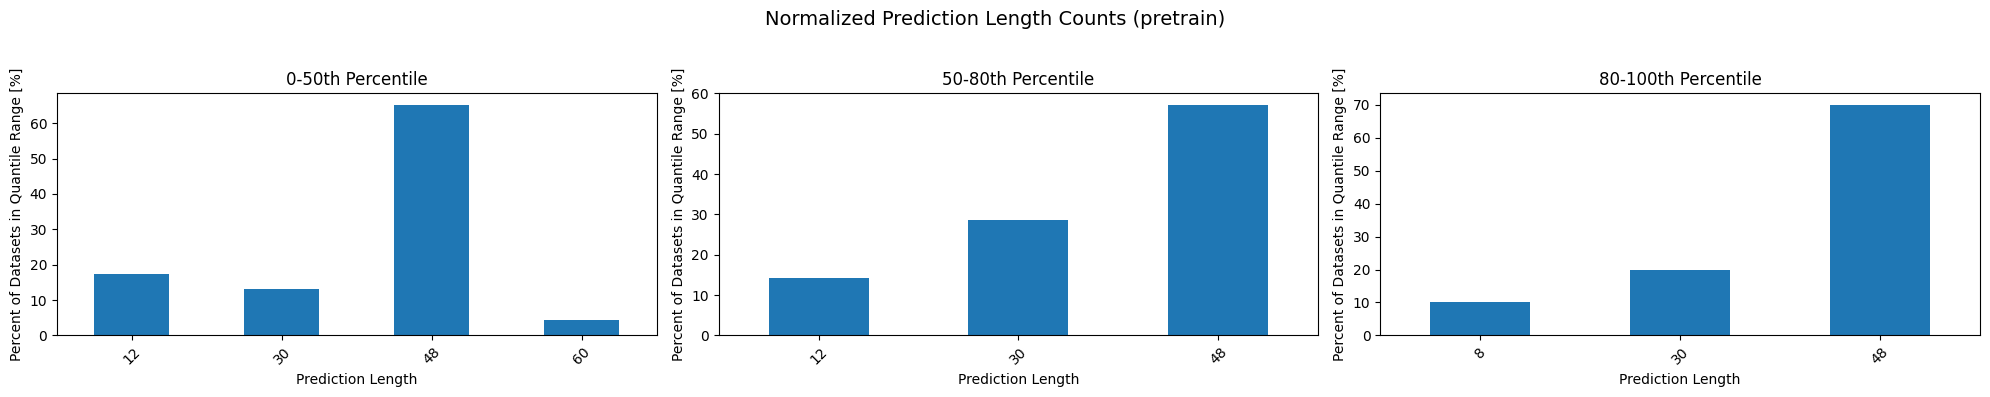

----------------------------------------------------------------------------------------------------------------------------------------------------------------


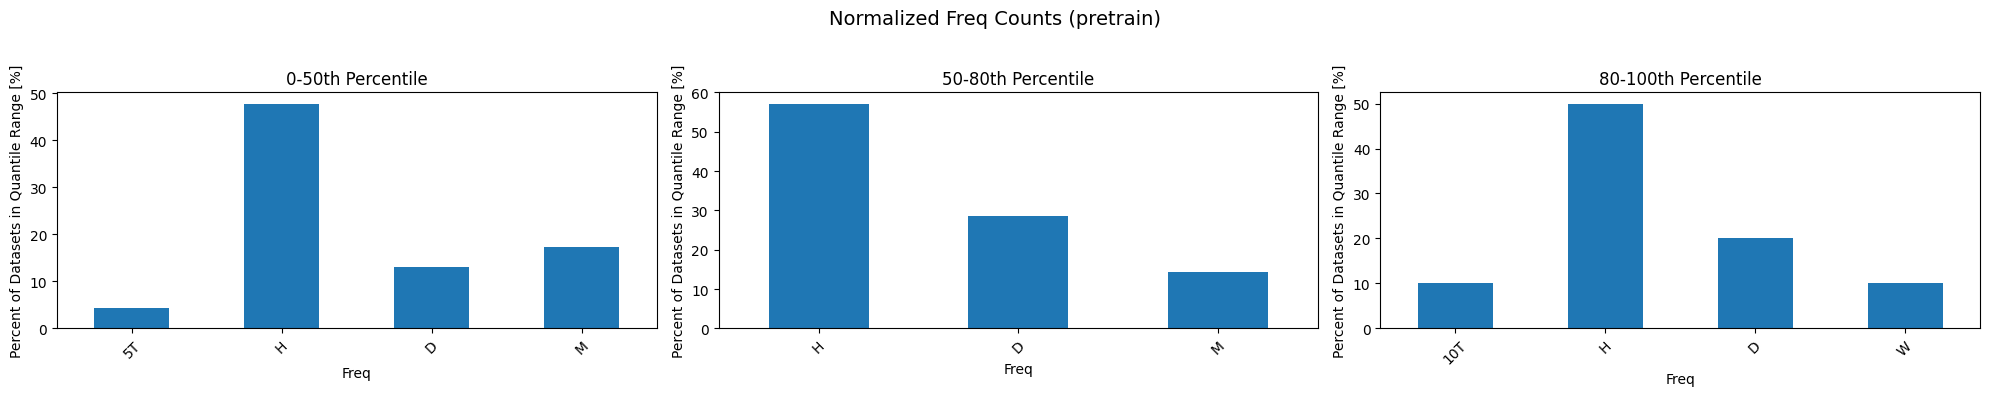

----------------------------------------------------------------------------------------------------------------------------------------------------------------


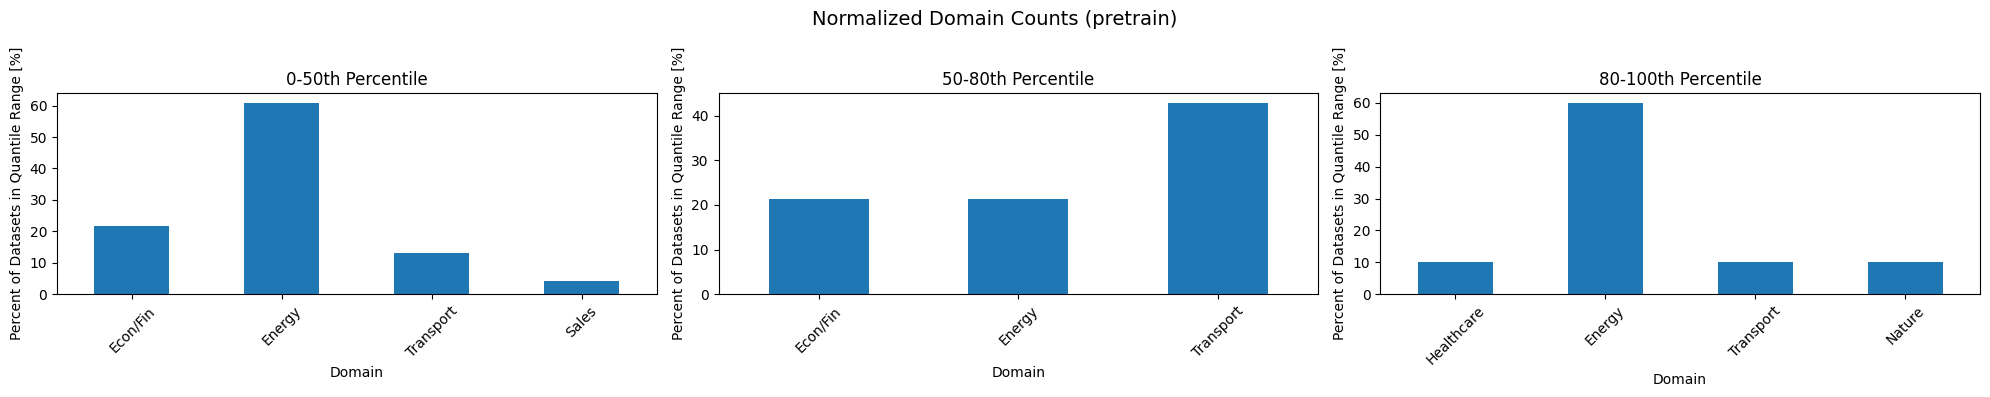

----------------------------------------------------------------------------------------------------------------------------------------------------------------


In [68]:
import matplotlib.pyplot as plt


def filter_by_quantile(df, target_col, q_start, q_end):
    """
    Returns a subset of the DataFrame where the target_col values
    fall between the q_start and q_end quantiles.

    Args:
        df (pd.DataFrame): The input DataFrame.
        target_col (str): Column name to compute quantiles on.
        q_start (float): Lower quantile (e.g., 0.25).
        q_end (float): Upper quantile (e.g., 0.5).

    Returns:
        pd.DataFrame: Filtered DataFrame.
    """
    q_lo = df[target_col].quantile(q_start)
    q_hi = df[target_col].quantile(q_end)
    return df[(df[target_col] >= q_lo) & (df[target_col] <= q_hi)]


def get_custom_order(value_col):
    if value_col == "freq":
        return [
            "10S",
            "5T",
            "10T",
            "15T",
            "H",
            "D",
            "W",
            "M",
            "Q",
            "A",
        ]
    else:
        return [
            "Healthcare",
            "Econ/Fin",
            "Energy",
            "Transport",
            "Nature",
            "Sales",
            "Web/CloudOps",
        ]


def plot_histogram(df, target_col, value_col, q_start, q_end, ax):
    """
    Plots a histogram of the number of datasets belonging to each category in
    value_col for rows in the target_col quantile range [q_start, q_end).

    Args:
        df (pd.DataFrame): The input DataFrame.
        target_col (str): Name of the numeric column to compute quantiles on.
        value_col (str): Name of the column whose counts will be plotted.
        q_start (float): Lower quantile bound (e.g. 0.25).
        q_end (float): Upper quantile bound (e.g. 0.5).
    """
    subset_df = filter_by_quantile(df, target_col, q_start, q_end)

    # Counts in the current bin
    counts = subset_df[value_col].value_counts().sort_index()

    # Percent of datasets in current bin that belong to each category
    percentages = (counts / counts.sum()).fillna(0).sort_index() * 100

    custom_order = (
        get_custom_order(value_col) if value_col in ["freq", "domain"] else None
    )

    if custom_order is not None:
        ordered_index = [val for val in custom_order if val in percentages.index]
        percentages = percentages.reindex(ordered_index)

    percentages.plot(kind="bar", ax=ax)
    col_name = value_col.replace("_", " ").title()
    ax.set_title(f"{int(q_start * 100)}-{int(q_end * 100)}th Percentile")
    ax.set_xlabel(col_name)
    ax.set_ylabel("Percent of Datasets in Quantile Range [%]")
    ax.tick_params(axis="x", rotation=45)


quantile_edges = [0, 0.5, 0.8, 1.0]
num_edges = len(quantile_edges)
num_bins = num_edges - 1
columns = ["prediction_length", "freq", "domain"]

for i, col in enumerate(columns):
    fig, axes = plt.subplots(
        1,
        num_bins,
        figsize=(5 * num_edges, 4),
    )

    fig.suptitle(
        f"Normalized {col.replace('_', ' ').title()} Counts ({split_name})",
        fontsize=14,
    )

    for j in range(num_bins):
        q_start, q_end = quantile_edges[j], quantile_edges[j + 1]
        plot_histogram(
            df=merged_df,
            target_col="crps",
            value_col=col,
            q_start=q_start,
            q_end=q_end,
            ax=axes[j],
        )

    # TODO: Consider using a pie chart instead of a bar chart
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    print("-" * 160)